dict_keys(['var_1515'])
Raw shape: (1, 5, 8400)
Detected palms: 5
Detected palms: 5


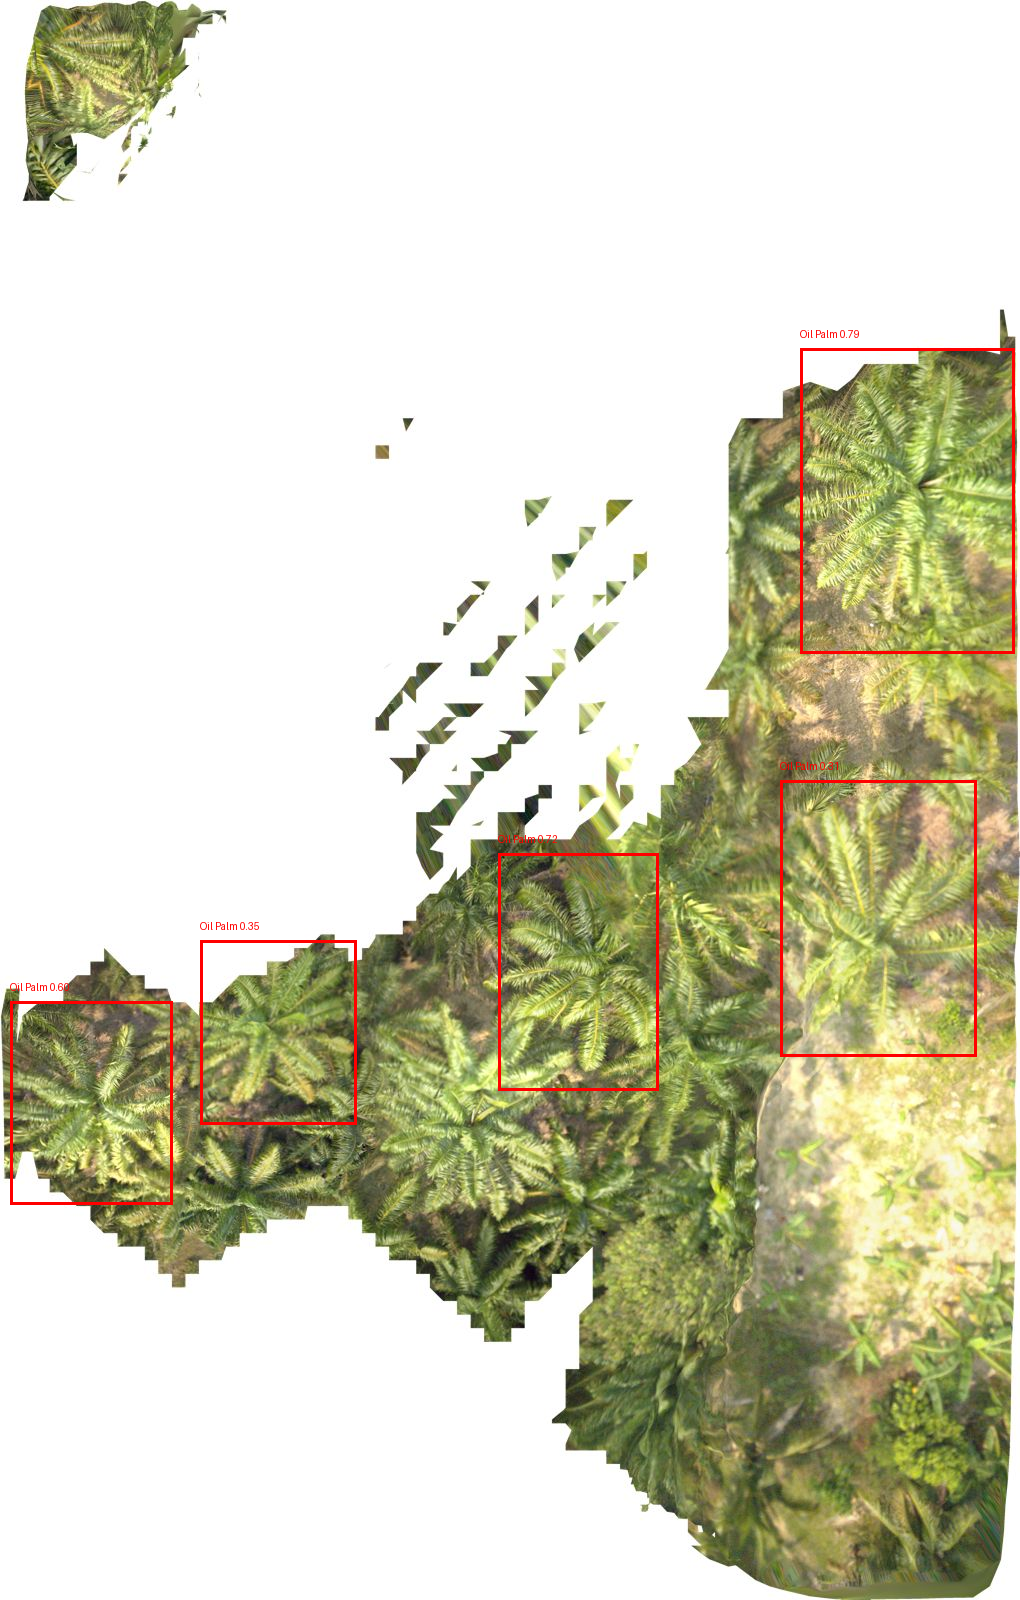

[0.78515625, 0.21787109375, 0.99453125, 0.40830078125] 0.79443359375
[0.4884765625, 0.533203125, 0.6458984375, 0.681640625] 0.7177734375
[0.0103515625, 0.6259765625, 0.16884765625, 0.7529296875] 0.60009765625
[0.196533203125, 0.5876953125, 0.349169921875, 0.7029296875] 0.345703125
[0.765625, 0.487890625, 0.9578125, 0.660546875] 0.314208984375

image 1/1 /Users/putragandadewata/Desktop/ADA_IL_Challenge/Krops-Challenge6/model/webodm_last_image.jpeg: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 4668.4ms
Speed: 4.0ms preprocess, 4668.4ms inference, 6.9ms postprocess per image at shape (1, 3, 1024, 1024)


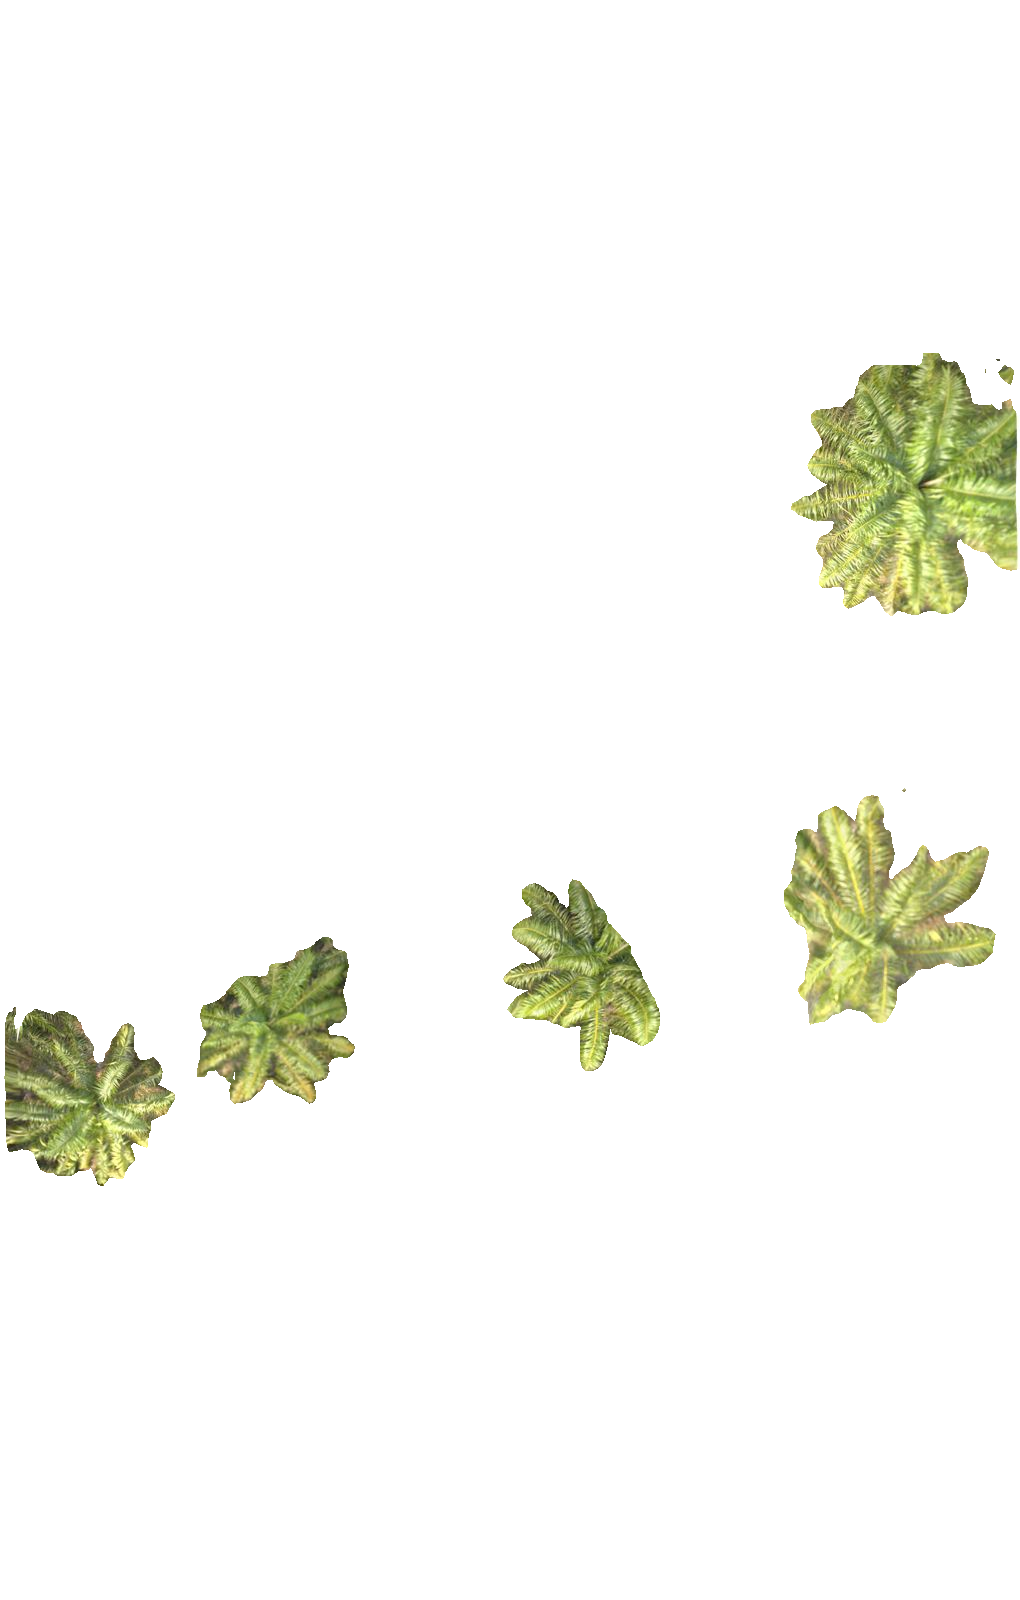

In [5]:
import coremltools as ct
import numpy as np
from PIL import Image
from ultralytics import SAM
import cv2


IMAGE_PATH = "webodm_last_image.jpeg"
MODEL_PATH = "yolo26m-krops-v0.1.mlpackage"

CONF_THRESHOLD = 0.05
IOU_THRESHOLD = 0.05


# --------------------------------------------------
# IoU
# --------------------------------------------------

def iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_w = max(0, x2 - x1)
    inter_h = max(0, y2 - y1)
    inter_area = inter_w * inter_h

    area1 = max(0, box1[2] - box1[0]) * max(0, box1[3] - box1[1])
    area2 = max(0, box2[2] - box2[0]) * max(0, box2[3] - box2[1])

    union = area1 + area2 - inter_area

    return inter_area / union if union > 0 else 0


# --------------------------------------------------
# NMS
# --------------------------------------------------

def nms(boxes, scores, iou_threshold=0.45):
    order = np.argsort(scores)[::-1]

    selected = []

    while len(order) > 0:
        i = order[0]
        selected.append(i)

        remaining = []

        for j in order[1:]:
            if iou(boxes[i], boxes[j]) <= iou_threshold:
                remaining.append(j)

        order = np.array(remaining)

    return selected


# --------------------------------------------------
# Load Core ML
# --------------------------------------------------

model = ct.models.MLModel(MODEL_PATH)

image = Image.open(IMAGE_PATH).convert("RGB")

# Your model expects 640x640
input_image = image.resize((640, 640))

prediction = model.predict({
    "image": input_image
})

# Find the output
print(prediction.keys())

raw = prediction["var_1515"]

print("Raw shape:", raw.shape)


# --------------------------------------------------
# Parse [1, 5, 8400]
# --------------------------------------------------

raw = np.asarray(raw)

# [1, 5, 8400] -> [8400, 5]
predictions = raw[0].T

boxes = []
scores = []

for pred in predictions:

    cx, cy, w, h, confidence = pred

    if confidence < CONF_THRESHOLD:
        continue

    # xywh -> xyxy
    x1 = cx - w / 2
    y1 = cy - h / 2
    x2 = cx + w / 2
    y2 = cy + h / 2

    # Normalize to 0..1
    x1 /= 640
    y1 /= 640
    x2 /= 640
    y2 /= 640

    # Clamp
    x1 = max(0, min(1, x1))
    y1 = max(0, min(1, y1))
    x2 = max(0, min(1, x2))
    y2 = max(0, min(1, y2))

    boxes.append([x1, y1, x2, y2])
    scores.append(float(confidence))


# --------------------------------------------------
# NMS
# --------------------------------------------------

selected = nms(
    boxes,
    scores,
    IOU_THRESHOLD
)

boxes = [boxes[i] for i in selected]
scores = [scores[i] for i in selected]

print(f"Detected palms: {len(boxes)}")

# --------------------------------------------------
# Display Core ML detection result
# --------------------------------------------------

from PIL import ImageDraw, ImageFont

detector_image = image.copy()
draw = ImageDraw.Draw(detector_image)

original_width, original_height = detector_image.size

for box, score in zip(boxes, scores):

    x1, y1, x2, y2 = box

    # Normalized -> original image coordinates
    x1 = int(x1 * original_width)
    y1 = int(y1 * original_height)
    x2 = int(x2 * original_width)
    y2 = int(y2 * original_height)

    # Draw bounding box
    draw.rectangle(
        [x1, y1, x2, y2],
        outline="red",
        width=3
    )

    # Draw confidence
    text = f"Oil Palm {score:.2f}"

    draw.text(
        (x1, max(0, y1 - 20)),
        text,
        fill="red"
    )

print(f"Detected palms: {len(boxes)}")

display(detector_image)


for box, score in zip(boxes, scores):
    print(box, score)


# --------------------------------------------------
# Convert normalized boxes to 640x640 pixel boxes
# for SAM
# --------------------------------------------------
sam_boxes = []

for box in boxes:

    x1, y1, x2, y2 = box

    sam_box = [
        x1 * original_width,
        y1 * original_height,
        x2 * original_width,
        y2 * original_height
    ]

    sam_boxes.append(
        sam_box
    )


# --------------------------------------------------
# SAM
# --------------------------------------------------

sam = SAM("sam_l.pt")

results = sam(
    IMAGE_PATH,
    bboxes=sam_boxes
)

result = results[0]


# --------------------------------------------------
# Combine all SAM masks
# --------------------------------------------------

original = np.array(image.convert("RGBA"))

combined_mask = np.zeros(
    original.shape[:2],
    dtype=bool
)

for mask_tensor in result.masks.data:

    mask = mask_tensor.cpu().numpy()

    # SAM mask should correspond to original image resolution
    combined_mask |= mask > 0


# --------------------------------------------------
# Transparent background
# --------------------------------------------------

alpha = (combined_mask * 255).astype(np.uint8)

output = original.copy()
output[:, :, 3] = alpha

output_image = Image.fromarray(output)

display(output_image)

# output_image.save("oil_palm_segmented.png")

# print("Saved: oil_palm_segmented.png")